<a href="https://colab.research.google.com/github/kukuhagushermawan/CVL_Assignment04/blob/main/CVL_Assignment04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CVL Assignment 04 [Template Matching dan Optical Flow]

**Nama**: Kukuh Agus Hermawan  
**NIM**: 24/533395/PA/22573

Notebook ini membandingkan dua metode tracking:
1. Template Matching dengan skor NCC.
2. Optical Flow dengan Lucas-Kanade lokal.

Dataset diakses dari link folder Google Drive. Ground truth diambil dari file PNG ground truth, lalu diubah menjadi bounding box target.


## 1. Konfigurasi link dataset

In [ ]:
from pathlib import Path

# Link folder Google Drive dataset
JPEG_FOLDER_URL = "https://drive.google.com/drive/folders/1i54vgH_0I2xnc4b6OJmzbdg4GP785DBS?usp=drive_link"
GT_FOLDER_URL = "https://drive.google.com/drive/folders/1IKaGR4MEbr-EdQLm_TYgp3ruN1ZRPxD1?usp=drive_link"

# Folder kerja dan folder output
WORK_DIR = Path("/content/CVL_Assignment04_DAVIS_LinkOnly")
JPEG_DOWNLOAD_DIR = WORK_DIR / "jpeg_from_drive"
GT_DOWNLOAD_DIR = WORK_DIR / "ground_truth_from_drive"
OUTPUT_DIR = WORK_DIR / "output"

# Batas jumlah frame
MAX_FRAMES = 80
FRAME_STEP = 1

# Target dari ground truth
# "auto" berarti target dipilih dari foreground terbesar pada ground truth.
TARGET_OBJECT_ID = "auto"

# Parameter Template Matching NCC
TEMPLATE_SEARCH_SCALE = 2.8
TEMPLATE_SEARCH_STEP = 3
TEMPLATE_UPDATE_ALPHA = 0.00

# Parameter Optical Flow Lucas-Kanade
MAX_POINTS = 160
MIN_POINT_DISTANCE = 7
FLOW_WINDOW = 13
MIN_LK_EIGENVALUE = 1e-4
MAX_FLOW_MAGNITUDE = 25
RESELECT_EVERY = 10

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Konfigurasi siap.")
print("Output disimpan di:", OUTPUT_DIR)

Konfigurasi siap.
Output disimpan di: /content/CVL_Assignment04_DAVIS_LinkOnly/output


## 2. Import library dan download dataset

In [ ]:
# Import library
import os
import sys
import time
import math
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Video


def ensure_gdown():
    try:
        import gdown
    except Exception:
        print("Menginstall gdown untuk download folder Google Drive...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown"])


def has_files(folder, exts):
    folder = Path(folder)
    if not folder.exists():
        return False
    exts = tuple(e.lower() for e in exts)
    return any(str(p).lower().endswith(exts) for p in folder.rglob("*"))


def run_command(cmd):
    result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    if result.stdout.strip():
        print(result.stdout[-1200:])
    if result.returncode != 0 and result.stderr.strip():
        print(result.stderr[-1200:])
    return result.returncode == 0


# Download folder Google Drive
def download_drive_folder(folder_url, output_dir, exts):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    if has_files(output_dir, exts):
        print("Folder sudah ada, skip download:", output_dir)
        return

    ensure_gdown()
    print("Download folder:", folder_url)
    print("Ke:", output_dir)

    cmd = [sys.executable, "-m", "gdown", "--folder", folder_url, "-O", str(output_dir), "--remaining-ok"]
    ok = run_command(cmd)

    if not ok:
        cmd = [sys.executable, "-m", "gdown", "--folder", folder_url, "-O", str(output_dir)]
        ok = run_command(cmd)

    if not ok or not has_files(output_dir, exts):
        raise RuntimeError(
            "Download gagal atau file tidak ditemukan. Pastikan folder Google Drive sudah "
            "dibagikan sebagai Anyone with the link - Viewer, lalu jalankan ulang cell ini."
        )


# Mencari folder yang paling banyak berisi frame atau ground truth
def find_dir_with_most_files(root, exts):
    root = Path(root)
    exts = tuple(e.lower() for e in exts)

    candidates = []
    for dirpath, _, filenames in os.walk(root):
        count = sum(name.lower().endswith(exts) for name in filenames)
        if count > 0:
            candidates.append((count, Path(dirpath)))

    if not candidates:
        raise FileNotFoundError(f"Tidak ada file {exts} di {root}")

    candidates.sort(reverse=True, key=lambda x: x[0])
    return candidates[0][1]


# Download frame JPEG dan ground truth PNG
download_drive_folder(JPEG_FOLDER_URL, JPEG_DOWNLOAD_DIR, exts=(".jpg", ".jpeg"))
download_drive_folder(GT_FOLDER_URL, GT_DOWNLOAD_DIR, exts=(".png",))

JPEG_DIR = find_dir_with_most_files(JPEG_DOWNLOAD_DIR, exts=(".jpg", ".jpeg"))
GT_DIR = find_dir_with_most_files(GT_DOWNLOAD_DIR, exts=(".png",))

print("JPEG_DIR        :", JPEG_DIR)
print("GROUND_TRUTH_DIR:", GT_DIR)

Folder sudah ada, skip download: /content/CVL_Assignment04_DAVIS_LinkOnly/jpeg_from_drive
Folder sudah ada, skip download: /content/CVL_Assignment04_DAVIS_LinkOnly/ground_truth_from_drive
JPEG_DIR        : /content/CVL_Assignment04_DAVIS_LinkOnly/jpeg_from_drive
GROUND_TRUTH_DIR: /content/CVL_Assignment04_DAVIS_LinkOnly/ground_truth_from_drive


## 3. Membaca frame dan ground truth

In [ ]:
IMG_EXTS = (".jpg", ".jpeg", ".png")
GT_EXTS = (".png",)


# Mengurutkan file berdasarkan nama frame, misalnya 00000, 00001, dst.
def sorted_files(folder, exts):
    folder = Path(folder)
    files = [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in exts]
    return sorted(files, key=lambda p: p.stem)


# Memasangkan frame JPEG dengan ground truth PNG berdasarkan nama file yang sama
def build_pairs(jpeg_dir, gt_dir):
    img_files = sorted_files(jpeg_dir, IMG_EXTS)
    gt_files = sorted_files(gt_dir, GT_EXTS)

    img_map = {p.stem: p for p in img_files}
    gt_map = {p.stem: p for p in gt_files}

    stems = sorted(set(img_map) & set(gt_map))
    if not stems:
        raise RuntimeError("Tidak ada pasangan frame JPEG dan ground truth PNG dengan nama file yang sama.")

    pairs = [(img_map[s], gt_map[s]) for s in stems]
    pairs = pairs[::FRAME_STEP]

    if MAX_FRAMES is not None:
        pairs = pairs[:MAX_FRAMES]

    return pairs


# Membaca frame dalam format BGR
def read_bgr(path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)
    return img


# Membaca frame dalam format RGB untuk visualisasi matplotlib
def read_rgb(path):
    return cv2.cvtColor(read_bgr(path), cv2.COLOR_BGR2RGB)


# Mengubah frame menjadi grayscale float 0 sampai 1
def read_gray_float(path_or_bgr):
    if isinstance(path_or_bgr, (str, Path)):
        bgr = read_bgr(path_or_bgr)
    else:
        bgr = path_or_bgr
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0


# Membaca ground truth PNG
def read_ground_truth(path):
    gt = np.array(Image.open(path))

    # Jika ground truth terbaca RGB, semua pixel non-background dianggap foreground.
    if gt.ndim == 3:
        gt = (np.any(gt[:, :, :3] > 0, axis=2)).astype(np.uint8)

    return gt


# Memilih object ID target dari foreground terbesar
def choose_object_id(gt):
    values, counts = np.unique(gt, return_counts=True)
    valid = values > 0
    values, counts = values[valid], counts[valid]

    if len(values) == 0:
        return None

    return int(values[np.argmax(counts)])


# Membuat mask biner khusus target yang dipilih
def ground_truth_to_binary(gt, object_id):
    return gt == object_id


# Mengubah mask ground truth menjadi bounding box [x1, y1, x2, y2]
def bbox_from_ground_truth(binary_gt):
    ys, xs = np.where(binary_gt)
    if len(xs) == 0:
        return None
    return [int(xs.min()), int(ys.min()), int(xs.max()) + 1, int(ys.max()) + 1]


# Membatasi bounding box agar tetap berada di dalam ukuran frame
def clamp_box(box, shape):
    h, w = shape[:2]
    x1, y1, x2, y2 = box
    x1 = int(np.clip(x1, 0, w - 1))
    y1 = int(np.clip(y1, 0, h - 1))
    x2 = int(np.clip(x2, x1 + 1, w))
    y2 = int(np.clip(y2, y1 + 1, h))
    return [x1, y1, x2, y2]


# Memperbesar bounding box untuk area pencarian Template Matching
def expand_box(box, scale, shape):
    x1, y1, x2, y2 = box
    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
    bw, bh = (x2 - x1) * scale, (y2 - y1) * scale
    return clamp_box([cx - bw / 2, cy - bh / 2, cx + bw / 2, cy + bh / 2], shape)


# Mengambil patch gambar berdasarkan bounding box
def crop_by_box(img, box):
    x1, y1, x2, y2 = clamp_box(box, img.shape)
    return img[y1:y2, x1:x2].copy()


# Membuat pasangan frame dan ground truth
pairs = build_pairs(JPEG_DIR, GT_DIR)
print("Jumlah pasangan frame-ground truth:", len(pairs))
print("Contoh pasangan:", pairs[0][0].name, "dan", pairs[0][1].name)

# Cari frame pertama yang memiliki target pada ground truth
start_index = None
selected_object_id = None

for i, (_, gt_path) in enumerate(pairs):
    gt = read_ground_truth(gt_path)
    oid = choose_object_id(gt) if TARGET_OBJECT_ID == "auto" else int(TARGET_OBJECT_ID)

    if oid is not None and np.any(gt == oid):
        start_index = i
        selected_object_id = oid
        break

if start_index is None:
    raise RuntimeError("Tidak ada foreground target pada ground truth.")

# Mulai tracking dari frame pertama yang valid
pairs = pairs[start_index:]

first_bgr = read_bgr(pairs[0][0])
first_gt = read_ground_truth(pairs[0][1])
first_binary_gt = ground_truth_to_binary(first_gt, selected_object_id)
initial_box = bbox_from_ground_truth(first_binary_gt)

print("Frame awal:", pairs[0][0].name)
print("Object ID ground truth:", selected_object_id)
print("Initial bounding box [x1, y1, x2, y2]:", initial_box)

Jumlah pasangan frame-ground truth: 37
Contoh pasangan: 00000.jpg dan 00000.png
Frame awal: 00000.jpg
Object ID ground truth: 1
Initial bounding box [x1, y1, x2, y2]: [313, 88, 655, 282]


## 4. Preview ground truth awal

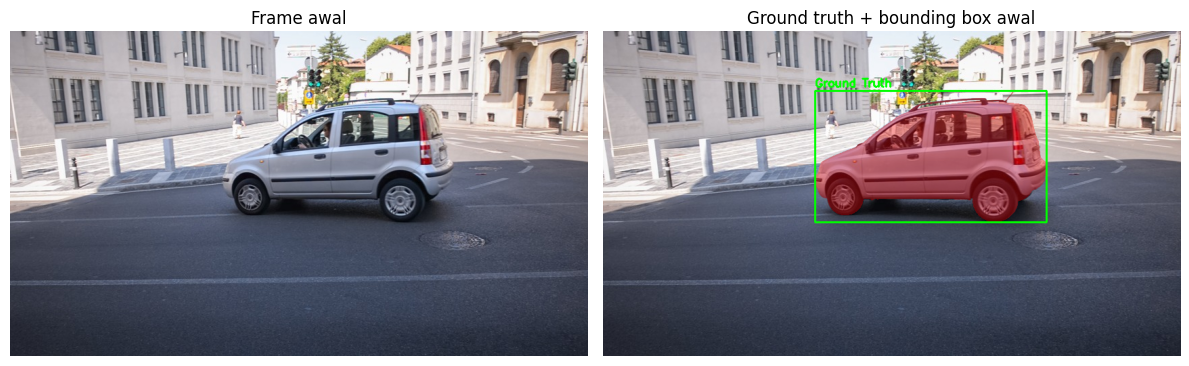

In [ ]:
# Menggambar bounding box pada gambar RGB
def draw_box_rgb(rgb, box, color=(0, 255, 0), thickness=2, label=None):
    out = rgb.copy()

    if box is not None:
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(out, (x1, y1), (x2, y2), color, thickness)

        if label:
            cv2.putText(out, label, (x1, max(18, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)

    return out


# Menampilkan frame awal dan area ground truth target
rgb0 = read_rgb(pairs[0][0])

overlay = rgb0.copy()
overlay[first_binary_gt] = (255, 0, 0)

preview = (0.65 * rgb0 + 0.35 * overlay).astype(np.uint8)
preview = draw_box_rgb(preview, initial_box, color=(0, 255, 0), label="Ground Truth")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(rgb0)
plt.title("Frame awal")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(preview)
plt.title("Ground truth + bounding box awal")
plt.axis("off")

plt.tight_layout()
plt.show()

## 5. Metode 1: Template Matching dengan NCC

Langkah:
1. Ambil target pada frame awal sebagai template.
2. Buat search window di sekitar posisi sebelumnya.
3. Geser template pada search window.
4. Hitung skor NCC tiap kandidat.
5. Pilih skor NCC tertinggi sebagai posisi target.

$$
NCC(T,P)=
\frac{\sum (T-\bar{T})(P-\bar{P})}
{\sqrt{\sum (T-\bar{T})^2 \sum (P-\bar{P})^2}}
$$

Keterangan:

- $T$ adalah template dari target pada frame awal.
- $P$ adalah patch kandidat pada frame saat ini.
- $\bar{T}$ adalah rata-rata intensitas template.
- $\bar{P}$ adalah rata-rata intensitas patch kandidat.
- Nilai NCC tertinggi menunjukkan patch yang paling mirip dengan template.

In [ ]:
# Menghitung skor kemiripan NCC
def ncc_score(template, patch, eps=1e-8):
    # Normalisasi template dan patch agar skor tidak terlalu dipengaruhi intensitas cahaya.
    t = template - float(template.mean())
    p = patch - float(patch.mean())

    denom = math.sqrt(float((t * t).sum()) * float((p * p).sum())) + eps
    return float((t * p).sum() / denom)


# Template Matching: geser template di area pencarian lalu pilih NCC tertinggi
def template_match_ncc(curr_gray, template_gray, prev_box, search_scale=TEMPLATE_SEARCH_SCALE, step=TEMPLATE_SEARCH_STEP):
    th, tw = template_gray.shape[:2]
    h, w = curr_gray.shape[:2]

    # Search window dibuat di sekitar posisi box sebelumnya.
    sx1, sy1, sx2, sy2 = expand_box(prev_box, search_scale, curr_gray.shape)
    sx2 = min(max(sx2, sx1 + tw), w)
    sy2 = min(max(sy2, sy1 + th), h)

    best_score = -np.inf
    best_box = clamp_box(prev_box, curr_gray.shape)

    max_x = sx2 - tw
    max_y = sy2 - th

    if max_x < sx1 or max_y < sy1:
        return best_box, float(best_score)

    # Template digeser per step pixel.
    for y in range(sy1, max_y + 1, step):
        for x in range(sx1, max_x + 1, step):
            patch = curr_gray[y:y + th, x:x + tw]

            if patch.shape != template_gray.shape:
                continue

            score = ncc_score(template_gray, patch)

            if score > best_score:
                best_score = score
                best_box = [x, y, x + tw, y + th]

    return best_box, float(best_score)


# Update template opsional; default alpha = 0 sehingga template awal tetap dipakai
def update_template(old_template, curr_gray, box, alpha=TEMPLATE_UPDATE_ALPHA):
    if alpha <= 0:
        return old_template

    new_patch = crop_by_box(curr_gray, box)

    if new_patch.shape != old_template.shape:
        return old_template

    return ((1 - alpha) * old_template + alpha * new_patch).astype(np.float32)

## 6. Metode 2: Optical Flow dengan Lucas-Kanade

Langkah:
1. Pilih titik fitur di dalam bounding box target.
2. Hitung gradien citra $I_x$, $I_y$, dan $I_t$.
3. Ambil window kecil di sekitar setiap titik fitur.
4. Hitung perpindahan titik menggunakan persamaan Lucas-Kanade.
5. Geser bounding box berdasarkan median perpindahan titik valid.

$$
I_xu + I_yv + I_t = 0
$$

Keterangan:

- $I_x$ adalah gradien citra arah horizontal.
- $I_y$ adalah gradien citra arah vertikal.
- $I_t$ adalah perubahan intensitas antar-frame.
- $u$ adalah perpindahan arah horizontal.
- $v$ adalah perpindahan arah vertikal.
- Bounding box target diperbarui dari perpindahan titik fitur.

In [ ]:
# Menghitung gradien Ix, Iy, dan It
def image_gradients(prev_gray, curr_gray):
    Ix = np.zeros_like(prev_gray, dtype=np.float32)
    Iy = np.zeros_like(prev_gray, dtype=np.float32)

    # Gradien spasial dihitung dari rata-rata dua frame agar lebih stabil.
    avg = 0.5 * (prev_gray + curr_gray)

    Ix[:, 1:-1] = (avg[:, 2:] - avg[:, :-2]) / 2.0
    Iy[1:-1, :] = (avg[2:, :] - avg[:-2, :]) / 2.0
    It = curr_gray - prev_gray

    return Ix, Iy, It


# Memilih titik fitur dari area target berdasarkan magnitude gradient
def select_feature_points(gray, box, max_points=MAX_POINTS, min_distance=MIN_POINT_DISTANCE):
    x1, y1, x2, y2 = clamp_box(box, gray.shape)
    margin = max(FLOW_WINDOW // 2 + 2, min_distance)

    Ix = np.zeros_like(gray, dtype=np.float32)
    Iy = np.zeros_like(gray, dtype=np.float32)

    Ix[:, 1:-1] = (gray[:, 2:] - gray[:, :-2]) / 2.0
    Iy[1:-1, :] = (gray[2:, :] - gray[:-2, :]) / 2.0

    # Semakin besar magnitude gradient, semakin kuat kandidat titik fiturnya.
    mag = Ix * Ix + Iy * Iy

    candidates = []
    y_start = max(y1 + margin, margin)
    y_end = min(y2 - margin, gray.shape[0] - margin)
    x_start = max(x1 + margin, margin)
    x_end = min(x2 - margin, gray.shape[1] - margin)

    for y in range(y_start, y_end):
        for x in range(x_start, x_end):
            candidates.append((float(mag[y, x]), x, y))

    candidates.sort(reverse=True, key=lambda t: t[0])

    selected = []
    min_dist2 = min_distance * min_distance

    # Ambil titik terkuat dengan jarak minimum antar titik.
    for score, x, y in candidates:
        if score <= 1e-7:
            break

        if all((x - px) ** 2 + (y - py) ** 2 >= min_dist2 for px, py in selected):
            selected.append((x, y))

        if len(selected) >= max_points:
            break

    return np.array(selected, dtype=np.float32)


# Menghitung optical flow satu titik dengan Lucas-Kanade lokal
def lk_flow_for_point(x, y, Ix, Iy, It, window=FLOW_WINDOW, min_eigen=MIN_LK_EIGENVALUE):
    r = window // 2
    xi, yi = int(round(x)), int(round(y))
    h, w = Ix.shape[:2]

    if xi - r < 0 or yi - r < 0 or xi + r >= w or yi + r >= h:
        return None

    # Ambil window lokal di sekitar titik.
    ix = Ix[yi - r:yi + r + 1, xi - r:xi + r + 1].reshape(-1)
    iy = Iy[yi - r:yi + r + 1, xi - r:xi + r + 1].reshape(-1)
    it = It[yi - r:yi + r + 1, xi - r:xi + r + 1].reshape(-1)

    # Susun sistem normal A [u, v] = b dari persamaan Ix*u + Iy*v + It = 0.
    A11 = float(np.sum(ix * ix))
    A12 = float(np.sum(ix * iy))
    A22 = float(np.sum(iy * iy))

    b1 = -float(np.sum(ix * it))
    b2 = -float(np.sum(iy * it))

    A = np.array([[A11, A12], [A12, A22]], dtype=np.float32)
    b = np.array([b1, b2], dtype=np.float32)

    # Titik dengan matriks lemah dibuang karena flow tidak stabil.
    eigvals = np.linalg.eigvalsh(A)
    if float(eigvals[0]) < min_eigen:
        return None

    try:
        flow = np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        return None

    u, v = float(flow[0]), float(flow[1])

    if not np.isfinite(u) or not np.isfinite(v):
        return None

    if math.sqrt(u * u + v * v) > MAX_FLOW_MAGNITUDE:
        return None

    return u, v


# Menggeser bounding box berdasarkan median perpindahan titik valid
def optical_flow_step(prev_gray, curr_gray, prev_box, points):
    Ix, Iy, It = image_gradients(prev_gray, curr_gray)

    valid_points = []
    flows = []

    for x, y in points:
        flow = lk_flow_for_point(x, y, Ix, Iy, It)

        if flow is None:
            continue

        u, v = flow
        valid_points.append([x + u, y + v])
        flows.append([u, v])

    if len(flows) < 5:
        return prev_box, np.empty((0, 2), dtype=np.float32), np.empty((0, 2), dtype=np.float32)

    flows = np.array(flows, dtype=np.float32)
    valid_points = np.array(valid_points, dtype=np.float32)

    # Median dipakai agar lebih tahan terhadap titik yang salah bergerak.
    dx, dy = np.median(flows, axis=0)

    x1, y1, x2, y2 = prev_box
    new_box = clamp_box([x1 + dx, y1 + dy, x2 + dx, y2 + dy], curr_gray.shape)

    # Simpan hanya titik yang masih berada di dalam bounding box baru.
    bx1, by1, bx2, by2 = new_box
    inside = (
        (valid_points[:, 0] >= bx1) & (valid_points[:, 0] < bx2) &
        (valid_points[:, 1] >= by1) & (valid_points[:, 1] < by2)
    )

    return new_box, valid_points[inside], flows[inside]

## 7. Helper IoU dan visualisasi

In [ ]:
# Menghitung IoU antara bounding box prediksi dan ground truth
def box_iou(box_a, box_b):
    if box_a is None or box_b is None:
        return np.nan

    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    # Area irisan kedua box
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)

    iw = max(0, ix2 - ix1)
    ih = max(0, iy2 - iy1)
    inter = iw * ih

    # Area gabungan kedua box
    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)
    union = area_a + area_b - inter

    return float(inter / union) if union > 0 else np.nan


# Menggambar Ground Truth, Template Matching, dan Optical Flow dalam satu frame
def draw_tracking_result(frame_bgr, gt_box, template_box, flow_box):
    out = frame_bgr.copy()

    if gt_box is not None:
        cv2.rectangle(out, tuple(gt_box[:2]), tuple(gt_box[2:]), (0, 255, 0), 2)
        cv2.putText(out, "Ground Truth", (gt_box[0], max(18, gt_box[1] - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 0), 2)

    if template_box is not None:
        cv2.rectangle(out, tuple(template_box[:2]), tuple(template_box[2:]), (255, 0, 0), 2)
        cv2.putText(out, "Template NCC", (template_box[0], max(38, template_box[1] - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 0, 0), 2)

    if flow_box is not None:
        cv2.rectangle(out, tuple(flow_box[:2]), tuple(flow_box[2:]), (0, 165, 255), 2)
        cv2.putText(out, "Optical Flow LK", (flow_box[0], max(58, flow_box[1] - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 165, 255), 2)

    return out

## 8. Metode 1: Template Matching

In [ ]:
# Menyimpan hasil tracking Template Matching
template_records = []
template_boxes = []

# Template awal diambil dari bounding box ground truth frame pertama
first_gray = read_gray_float(pairs[0][0])
template_gray = crop_by_box(first_gray, initial_box)
template_box = initial_box.copy()

print("Ukuran template:", template_gray.shape)

# Mulai hitung waktu komputasi Template Matching
total_start = time.perf_counter()

for frame_idx, (img_path, gt_path) in enumerate(pairs):
    curr_gray = read_gray_float(img_path)
    curr_gt = read_ground_truth(gt_path)
    gt_binary = ground_truth_to_binary(curr_gt, selected_object_id)
    gt_box = bbox_from_ground_truth(gt_binary)

    if frame_idx == 0:
        # Frame pertama memakai ground truth sebagai posisi awal.
        ncc = 1.0
        compute_time = 0.0
    else:
        # Frame berikutnya dicari dengan Template Matching NCC.
        start_time = time.perf_counter()
        template_box, ncc = template_match_ncc(curr_gray, template_gray, template_box)
        template_gray = update_template(template_gray, curr_gray, template_box)
        compute_time = time.perf_counter() - start_time

    template_boxes.append(template_box.copy())

    # Simpan IoU dan waktu per frame.
    template_records.append({
        "frame_index": frame_idx,
        "file_name": img_path.name,
        "gt_box": gt_box,
        "template_box": template_box.copy(),
        "template_iou": box_iou(gt_box, template_box),
        "template_ncc": ncc,
        "template_time_sec": compute_time,
    })

template_total_time = time.perf_counter() - total_start
template_results = pd.DataFrame(template_records)

template_mean_time = template_results["template_time_sec"].iloc[1:].mean()
template_fps = 1.0 / template_mean_time if template_mean_time > 0 else np.nan

print("Template Matching selesai.")
print("Total waktu komputasi       :", round(template_total_time, 4), "detik")
print("Rata-rata waktu per frame   :", round(template_mean_time, 4), "detik")
print("Approx FPS                  :", round(template_fps, 2))
print("Mean IoU                    :", round(template_results["template_iou"].mean(), 4))

display(template_results[["frame_index", "file_name", "template_iou", "template_ncc", "template_time_sec"]].head())

Ukuran template: (194, 342)
Template Matching selesai.
Total waktu komputasi       : 148.7949 detik
Rata-rata waktu per frame   : 4.1239 detik
Approx FPS                  : 0.24
Mean IoU                    : 0.3499


,frame_index,file_name,template_iou,template_ncc,template_time_sec
0,0,00000.jpg,1.000000,1.000000,0.000000
1,1,00001.jpg,0.970293,0.855841,12.858787
2,2,00002.jpg,0.950745,0.833989,4.119037
3,3,00003.jpg,0.921640,0.762097,5.359535
4,4,00004.jpg,0.888135,0.720924,4.421835


### Analisis Template Matching

Template Matching berhasil melacak target menggunakan template awal dan skor NCC. Pada awal frame, nilai IoU tinggi karena tampilan target masih mirip dengan template awal. Namun, setelah beberapa frame, performa menurun karena posisi, skala, dan tampilan target berubah.

Hasil menunjukkan:
- Mean IoU Template Matching = 0.3499
- Total waktu komputasi = 148.7949 detik
- Rata-rata waktu per frame = 4.1239 detik
- Approx FPS = 0.24

Artinya, metode ini cukup baik di awal tracking, tetapi kurang stabil ketika target mengalami perubahan tampilan. Waktu komputasinya juga lebih besar karena template harus digeser dan dihitung skor NCC pada banyak kandidat posisi.

## 9. Metode 2: Optical Flow

In [ ]:
# Menyimpan hasil tracking Optical Flow
flow_records = []
flow_boxes = []

# Optical Flow dimulai dari bounding box ground truth frame pertama
prev_gray = read_gray_float(pairs[0][0])
flow_box = initial_box.copy()
flow_points = select_feature_points(prev_gray, flow_box)

print("Jumlah titik awal Optical Flow:", len(flow_points))

# Mulai hitung waktu komputasi Optical Flow
total_start = time.perf_counter()

for frame_idx, (img_path, gt_path) in enumerate(pairs):
    curr_gray = read_gray_float(img_path)
    curr_gt = read_ground_truth(gt_path)
    gt_binary = ground_truth_to_binary(curr_gt, selected_object_id)
    gt_box = bbox_from_ground_truth(gt_binary)

    if frame_idx == 0:
        # Frame pertama memakai ground truth sebagai posisi awal.
        compute_time = 0.0
    else:
        # Pilih ulang titik jika jumlah titik terlalu sedikit atau sudah beberapa frame.
        if frame_idx % RESELECT_EVERY == 0 or len(flow_points) < 20:
            flow_points = select_feature_points(prev_gray, flow_box)

        # Hitung perpindahan titik dan geser bounding box.
        start_time = time.perf_counter()
        flow_box, flow_points, _ = optical_flow_step(prev_gray, curr_gray, flow_box, flow_points)
        compute_time = time.perf_counter() - start_time

    flow_boxes.append(flow_box.copy())

    # Simpan IoU, waktu, dan jumlah titik valid per frame.
    flow_records.append({
        "frame_index": frame_idx,
        "file_name": img_path.name,
        "gt_box": gt_box,
        "flow_box": flow_box.copy(),
        "flow_iou": box_iou(gt_box, flow_box),
        "flow_time_sec": compute_time,
        "flow_point_count": int(len(flow_points)),
    })

    prev_gray = curr_gray

flow_total_time = time.perf_counter() - total_start
flow_results = pd.DataFrame(flow_records)

flow_mean_time = flow_results["flow_time_sec"].iloc[1:].mean()
flow_fps = 1.0 / flow_mean_time if flow_mean_time > 0 else np.nan

print("Optical Flow selesai.")
print("Total waktu komputasi       :", round(flow_total_time, 4), "detik")
print("Rata-rata waktu per frame   :", round(flow_mean_time, 4), "detik")
print("Approx FPS                  :", round(flow_fps, 2))
print("Mean IoU                    :", round(flow_results["flow_iou"].mean(), 4))

display(flow_results[["frame_index", "file_name", "flow_iou", "flow_time_sec", "flow_point_count"]].head())

Jumlah titik awal Optical Flow: 160
Optical Flow selesai.
Total waktu komputasi       : 0.9813 detik
Rata-rata waktu per frame   : 0.0151 detik
Approx FPS                  : 66.26
Mean IoU                    : 0.5164


,frame_index,file_name,flow_iou,flow_time_sec,flow_point_count
0,0,00000.jpg,1.000000,0.000000,160
1,1,00001.jpg,0.931368,0.030808,160
2,2,00002.jpg,0.866947,0.014068,160
3,3,00003.jpg,0.811166,0.013868,158
4,4,00004.jpg,0.761792,0.016226,157


### Analisis Optical Flow

Optical Flow berhasil melacak target berdasarkan perpindahan titik fitur antar-frame. Metode ini menghitung gerakan lokal dari titik-titik fitur di dalam bounding box target.

Hasil menunjukkan:
- Mean IoU Optical Flow = 0.5164
- Total waktu komputasi = 0.9813 detik
- Rata-rata waktu per frame = 0.0151 detik
- Approx FPS = 66.26

Artinya, Optical Flow lebih cepat dan lebih stabil dibandingkan Template Matching pada data ini. Metode ini mampu mengikuti pergerakan target dengan baik selama titik fitur masih valid dan tidak banyak hilang.

## 10. Evaluasi IoU dan waktu komputasi

Evaluasi akurasi memakai **IoU** karena ground truth tersedia dalam bentuk bounding box dari file ground truth PNG.


In [ ]:
# Menggabungkan hasil dua metode dalam tabel
results = pd.DataFrame({
    "frame_index": template_results["frame_index"],
    "file_name": template_results["file_name"],
    "gt_box": template_results["gt_box"],
    "template_box": template_results["template_box"],
    "flow_box": flow_results["flow_box"],
    "template_iou": template_results["template_iou"],
    "flow_iou": flow_results["flow_iou"],
    "template_time_sec": template_results["template_time_sec"],
    "flow_time_sec": flow_results["flow_time_sec"],
})

# Ringkasan nilai IoU dan waktu komputasi
summary = pd.DataFrame({
    "Metode": [
        "Template Matching NCC",
        "Optical Flow Lucas-Kanade",
    ],
    "Mean IoU": [
        results["template_iou"].mean(),
        results["flow_iou"].mean(),
    ],
    "Median IoU": [
        results["template_iou"].median(),
        results["flow_iou"].median(),
    ],
    "Total Time (s)": [
        template_total_time,
        flow_total_time,
    ],
    "Mean Time / Frame (s)": [
        results["template_time_sec"].iloc[1:].mean(),
        results["flow_time_sec"].iloc[1:].mean(),
    ],
})

summary["Approx FPS"] = 1.0 / summary["Mean Time / Frame (s)"].replace(0, np.nan)

# Tampilkan summary dan beberapa baris hasil per frame
display(summary)
display(results[["frame_index", "file_name", "template_iou", "flow_iou", "template_time_sec", "flow_time_sec"]].head())

,Metode,Mean IoU,Median IoU,Total Time (s),Mean Time / Frame (s),Approx FPS
0,Template Matching NCC,0.349915,0.005703,148.794940,4.123905,0.242489
1,Optical Flow Lucas-Kanade,0.516357,0.471475,0.981314,0.015093,66.257153


,frame_index,file_name,template_iou,flow_iou,template_time_sec,flow_time_sec
0,0,00000.jpg,1.000000,1.000000,0.000000,0.000000
1,1,00001.jpg,0.970293,0.931368,12.858787,0.030808
2,2,00002.jpg,0.950745,0.866947,4.119037,0.014068
3,3,00003.jpg,0.921640,0.811166,5.359535,0.013868
4,4,00004.jpg,0.888135,0.761792,4.421835,0.016226


### Analisis Evaluasi

Evaluasi dilakukan menggunakan IoU karena ground truth sudah tersedia dalam bentuk bounding box dari mask PNG. Semakin tinggi nilai IoU, semakin dekat hasil tracking dengan ground truth.

Berdasarkan hasil evaluasi, Optical Flow memperoleh Mean IoU lebih tinggi dibandingkan Template Matching. Optical Flow juga memiliki waktu komputasi jauh lebih kecil, sehingga lebih efisien untuk tracking pada data ini.

Template Matching memiliki waktu komputasi lebih lama karena setiap frame harus mencari posisi terbaik dengan menggeser template pada search window. Optical Flow lebih cepat karena hanya menghitung perpindahan titik fitur yang terpilih.

## 11. Grafik perbandingan

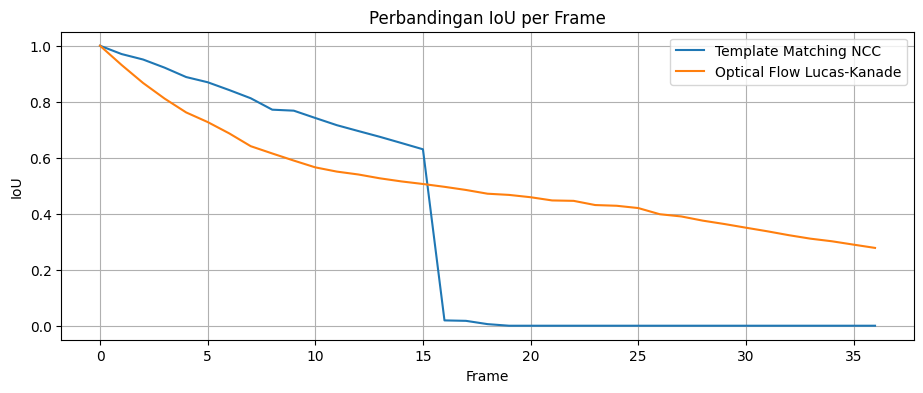

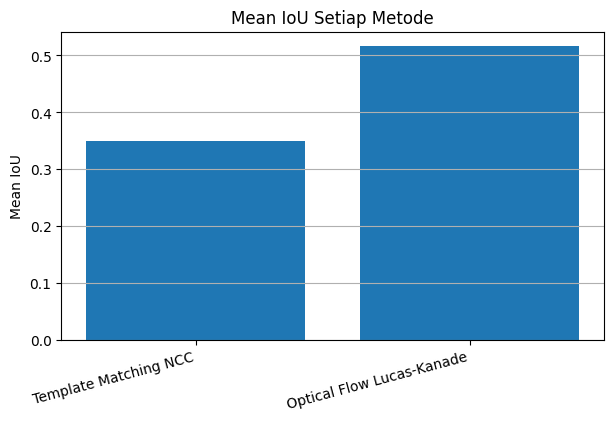

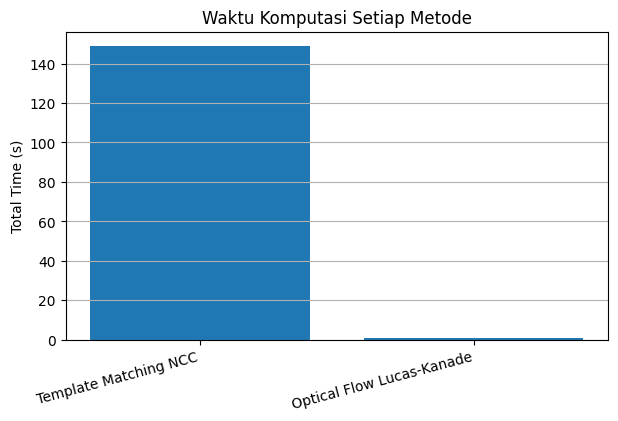

In [ ]:
# Grafik IoU per frame untuk melihat stabilitas tracking
plt.figure(figsize=(11, 4))
plt.plot(results["frame_index"], results["template_iou"], label="Template Matching NCC")
plt.plot(results["frame_index"], results["flow_iou"], label="Optical Flow Lucas-Kanade")
plt.xlabel("Frame")
plt.ylabel("IoU")
plt.title("Perbandingan IoU per Frame")
plt.legend()
plt.grid(True)
plt.show()


# Grafik rata-rata IoU setiap metode
plt.figure(figsize=(7, 4))
plt.bar(summary["Metode"], summary["Mean IoU"])
plt.ylabel("Mean IoU")
plt.title("Mean IoU Setiap Metode")
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y")
plt.show()


# Grafik waktu komputasi total setiap metode
plt.figure(figsize=(7, 4))
plt.bar(summary["Metode"], summary["Total Time (s)"])
plt.ylabel("Total Time (s)")
plt.title("Waktu Komputasi Setiap Metode")
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y")
plt.show()

### Analisis Grafik

Grafik IoU per frame menunjukkan bahwa Template Matching memiliki IoU tinggi pada awal frame, tetapi nilainya turun tajam setelah target mulai berubah posisi dan tampilan. Optical Flow terlihat lebih stabil karena mengikuti perpindahan target antar-frame.

Grafik Mean IoU menunjukkan bahwa Optical Flow memiliki rata-rata IoU lebih tinggi dibandingkan Template Matching. Grafik waktu komputasi juga menunjukkan bahwa Optical Flow jauh lebih cepat daripada Template Matching.

## 12. Preview hasil tracking

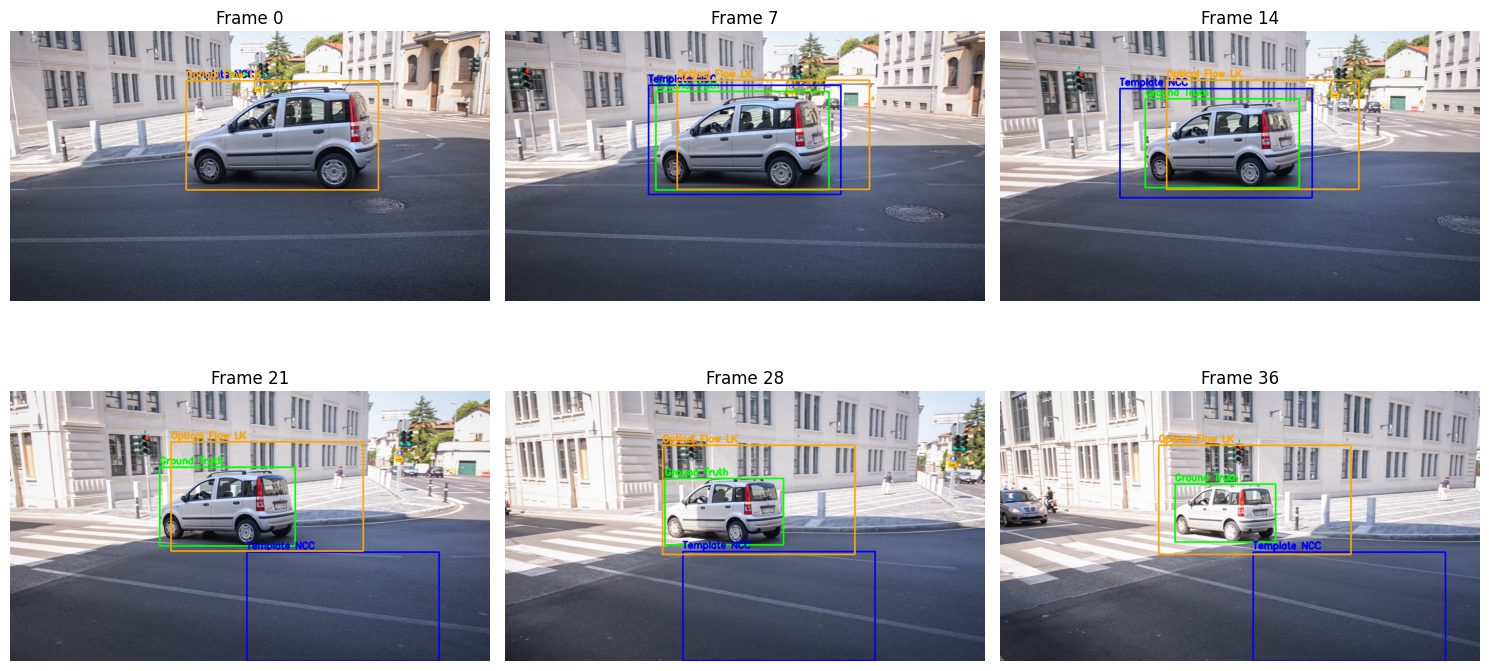

In [ ]:
# Membuat frame visual berisi Ground Truth, Template Matching, dan Optical Flow
visual_frames = []

for i, (img_path, _) in enumerate(pairs):
    frame_bgr = read_bgr(img_path)
    visual = draw_tracking_result(
        frame_bgr,
        results.loc[i, "gt_box"],
        results.loc[i, "template_box"],
        results.loc[i, "flow_box"],
    )
    visual_frames.append(visual)

# Ambil beberapa frame contoh untuk preview di notebook
sample_ids = np.linspace(0, len(visual_frames) - 1, min(6, len(visual_frames)), dtype=int)

plt.figure(figsize=(15, 8))

for plot_idx, frame_idx in enumerate(sample_ids, 1):
    plt.subplot(2, 3, plot_idx)
    plt.imshow(cv2.cvtColor(visual_frames[frame_idx], cv2.COLOR_BGR2RGB))
    plt.title(f"Frame {frame_idx}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Preview Tracking

Preview hasil tracking memperlihatkan perbandingan antara Ground Truth, Template Matching, dan Optical Flow. Ground Truth menjadi acuan posisi target sebenarnya. Bounding box Template Matching mulai kurang sesuai pada beberapa frame ketika tampilan target berubah. Sementara itu, Optical Flow cenderung lebih dekat dengan Ground Truth karena mengikuti arah gerakan target dari frame sebelumnya.

Secara visual, Optical Flow memberikan hasil tracking yang lebih baik dan lebih konsisten pada data ini.

## 13. Export video perbandingan

In [ ]:
# Menyimpan hasil visualisasi tracking menjadi 1 video comparison
def write_video(frames_bgr, path, fps=12):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    if len(frames_bgr) == 0:
        raise ValueError("Tidak ada frame untuk diekspor. Jalankan cell preview hasil tracking terlebih dahulu.")

    h, w = frames_bgr[0].shape[:2]

    writer = cv2.VideoWriter(
        str(path),
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (w, h)
    )

    if not writer.isOpened():
        raise RuntimeError(f"Gagal membuat video writer untuk: {path}")

    for frame in frames_bgr:
        frame = np.asarray(frame)

        if frame.dtype != np.uint8:
            frame = np.clip(frame, 0, 255).astype(np.uint8)

        if frame.shape[:2] != (h, w):
            frame = cv2.resize(frame, (w, h))

        writer.write(frame)

    writer.release()
    return path


# Output akhir: satu video perbandingan Ground Truth dengan dua metode tracking
video_path = OUTPUT_DIR / "tracking_comparison_groundtruth_template_opticalflow.mp4"
write_video(visual_frames, video_path, fps=12)

print("Video perbandingan tersimpan di:")
print(video_path)

display(Video(str(video_path), embed=True))

Video perbandingan tersimpan di:
/content/CVL_Assignment04_DAVIS_LinkOnly/output/tracking_comparison_groundtruth_template_opticalflow.mp4


## Kesimpulan

Berdasarkan hasil eksperimen, kedua metode berhasil diimplementasikan dan dibandingkan menggunakan metrik IoU serta waktu komputasi.

Template Matching dengan NCC bekerja dengan mencari patch yang paling mirip dengan template awal. Metode ini cukup baik pada awal frame, tetapi performanya menurun ketika target mengalami perubahan posisi, skala, atau tampilan.

Optical Flow dengan Lucas-Kanade bekerja dengan menghitung perpindahan titik fitur antar-frame. Pada data ini, Optical Flow menghasilkan Mean IoU lebih tinggi dan waktu komputasi lebih cepat dibandingkan Template Matching.

Dengan demikian, metode terbaik pada eksperimen ini adalah Optical Flow Lucas-Kanade karena lebih akurat, lebih stabil, dan lebih efisien untuk melacak target pada urutan frame yang digunakan.